## Imports

In [1]:
import logging
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import pandas as pd
from lifelines import WeibullAFTFitter, LogLogisticAFTFitter, LogNormalAFTFitter
from lifelines.plotting import plot_lifetimes
from sklearn.preprocessing import LabelEncoder

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

## data management

In [3]:
def load_data(filepath: Path) -> pd.DataFrame:
    logger.info("Loading data from %s", filepath)
    df = pd.read_csv(filepath)
    required_cols = {"tenure", "churn"}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns: {missing}")
    return df


def preprocess(df: pd.DataFrame, id_column: str = "ID") -> pd.DataFrame:
    df = df.copy()
    df["churn"] = df["churn"].map({"Yes": 1, "No": 0})
    if df["churn"].isnull().any():
        raise ValueError("Found churn values outside {'Yes','No'}")

    # Label‐encode all object dtypes except ID
    object_cols = [
        col for col in df.select_dtypes(include="object").columns
        if col != id_column
    ]
    logger.info("Encoding columns: %s", object_cols)
    for col in object_cols:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))
    return df

## models

In [4]:
def fit_all_models(
    df: pd.DataFrame,
    duration_col: str,
    event_col: str
) -> Tuple[Dict[str, object], Dict[str, float]]:
    model_classes = {
        "WeibullAFT": WeibullAFTFitter,
        "LogLogisticAFT": LogLogisticAFTFitter,
        "LogNormalAFT": LogNormalAFTFitter,
    }
    fitted_models: Dict[str, object] = {}
    aic_scores: Dict[str, float] = {}

    for name, Model in model_classes.items():
        logger.info("Fitting %s...", name)
        model = Model()
        model.fit(df, duration_col=duration_col, event_col=event_col)
        fitted_models[name] = model
        aic_scores[name] = model.AIC_
        logger.info("%s AIC: %.2f", name, model.AIC_)
        logger.debug("%s summary:\n%s", name, model.summary)

    return fitted_models, aic_scores


## plots

In [5]:
def plot_survival_curves(
    fitted_models: Dict[str, object],
    df: pd.DataFrame,
    duration_col: str,
    title: str = "AFT Survival Curves (Median Customer)",
) -> None:
    median_covariates = df.median().to_frame().T
    plt.figure(figsize=(10, 6))
    for name, model in fitted_models.items():
        surv = model.predict_survival_function(median_covariates)
        plt.plot(surv.index, surv.values.flatten(), label=name)

    plt.title(title)
    plt.xlabel(duration_col)
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    logger.info("Displaying survival curves plot.")
    plt.show()

In [6]:
def select_best_model(aic_scores: Dict[str, float]) -> str:
    best = min(aic_scores, key=aic_scores.get)
    logger.info("Best model by AIC: %s (AIC=%.2f)", best, aic_scores[best])
    return best

## Final

2025-05-01 21:49:28 INFO Loading data from telco.csv
2025-05-01 21:49:28 INFO Encoding columns: ['region', 'marital', 'ed', 'retire', 'gender', 'voice', 'internet', 'forward', 'custcat']
2025-05-01 21:49:28 INFO Fitting WeibullAFT...
2025-05-01 21:49:29 INFO WeibullAFT AIC: 2973.91
2025-05-01 21:49:29 INFO Fitting LogLogisticAFT...
2025-05-01 21:49:29 INFO LogLogisticAFT AIC: 2963.72
2025-05-01 21:49:29 INFO Fitting LogNormalAFT...
2025-05-01 21:49:29 INFO LogNormalAFT AIC: 2960.11
2025-05-01 21:49:30 INFO Displaying survival curves plot.



Model AIC Scores:
  - WeibullAFT: 2973.91
  - LogLogisticAFT: 2963.72
  - LogNormalAFT: 2960.11


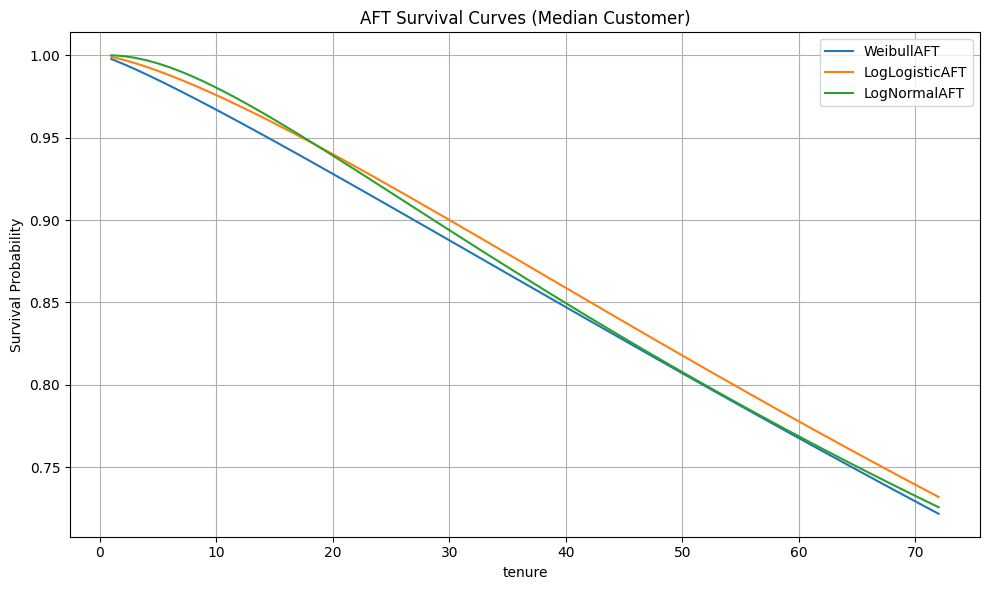

2025-05-01 21:49:30 INFO Best model by AIC: LogNormalAFT (AIC=2960.11)



Final Model Selected: LogNormalAFT


In [7]:
data_path = Path("telco.csv")
df_raw = load_data(data_path)
df_enc = preprocess(df_raw, id_column="ID")

duration = "tenure"
event = "churn"

models, aics = fit_all_models(df_enc, duration_col=duration, event_col=event)

print("\nModel AIC Scores:")
for name, score in aics.items():
    print(f"  - {name}: {score:.2f}")

plot_survival_curves(models, df_enc, duration_col=duration)

best = select_best_model(aics)
print(f"\nFinal Model Selected: {best}")

## CLV

In [9]:
final_model = LogNormalAFTFitter()
final_model.fit(df_enc, duration_col="tenure", event_col="churn")

predicted_lifetime = final_model.predict_median(df_enc)

monthly_revenue = 50     
discount_rate = 0.01      # monthly discount rate (e.g., 1%)

clv = (monthly_revenue * (1 - (1 + discount_rate) ** (-predicted_lifetime))) / discount_rate

df_enc["predicted_lifetime"] = predicted_lifetime
df_enc["CLV"] = clv

df_clv_segments = df_enc[["ID", "region", "custcat", "income", "CLV"]]

In [10]:
df_clv_segments

,ID,region,custcat,income,CLV
0,1,1,0,64,3099.178917
1,2,2,3,136,4098.141081
2,3,2,2,116,4999.306700
3,4,1,0,33,2596.012094
4,5,1,2,30,3900.010803
...,...,...,...,...,...
995,996,2,0,27,1562.843896
996,997,0,0,22,1286.890085
997,998,2,3,944,4992.606988
998,999,2,2,87,3262.642949
